# Exploratory Data Analysis - Mutual Fund Analytics

This notebook performs Exploratory Data Analysis (EDA) on mutual fund historical data, including Net Asset Value (NAV) trends, Assets Under Management (AUM), investor transactions (SIPs vs Lumpsums vs Redemptions), and performance vs expense ratios.


In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)

# Create reports/charts directory if it doesn't exist
os.makedirs("../reports/charts", exist_ok=True)

# Connect to database
db_path = "../data/mutual_fund_analytics.db"
conn = sqlite3.connect(db_path)
print("Connected to database successfully.")

Connected to database successfully.


In [2]:
# 1. NAV Trends Over Time (2022-2026)
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv",
    parse_dates=["date"]
)

# Fetch fund names from raw master to map them
fund_master = pd.read_csv("../data/raw/fund_master.csv")
nav = nav.merge(fund_master[['scheme_code', 'scheme_name']], on='scheme_code', how='left')

# Filter for the 2022-2026 date range
nav = nav[(nav['date'] >= '2022-01-01') & (nav['date'] <= '2026-12-31')]

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)

# Bull run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run"
)

# Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Market Correction"
)

# Save chart as static PNG image
fig.write_image("../reports/charts/nav_trend.png")

# Display the interactive plot
fig.show()

/var/folders/rc/9j4p8rqs3_l7zkv7njn9q9yc0000gn/T/ipykernel_15670/942114637.py:22: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rc/9j4p8rqs3_l7zkv7njn9q9yc0000gn/T/ipykernel_15670/942114637.py:24: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig("../reports/charts/aum_growth.png")
/Users/ronitchugwani/Desktop/mutual-fund-analytics/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


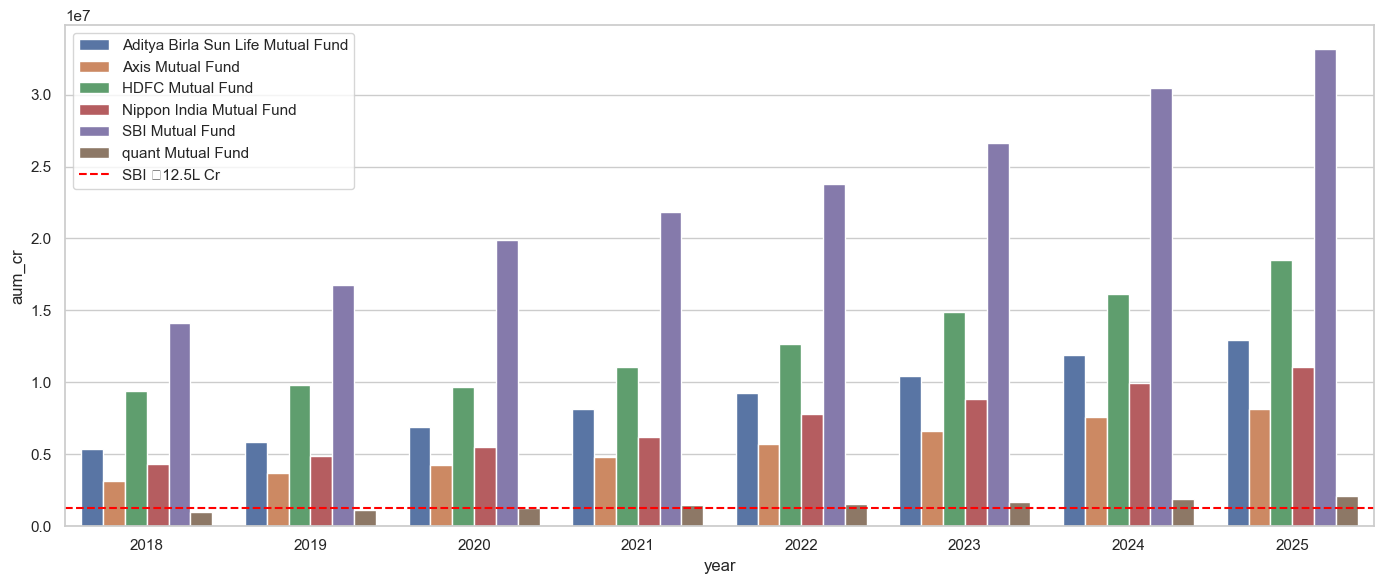

In [3]:
# 2. AUM Growth Over Time
aum = pd.read_csv("../data/processed/aum_history.csv")

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_cr",
    hue="fund_house"
)

plt.axhline(
    1250000,
    color="red",
    linestyle="--",
    label="SBI ₹12.5L Cr"
)

plt.legend()

plt.tight_layout()

plt.savefig("../reports/charts/aum_growth.png")
plt.show()

In [4]:
# 3. Monthly SIP Trend
sip = pd.read_csv(
    "../data/processed/monthly_sip.csv",
    parse_dates=["month"]
)

fig = px.line(
    sip,
    x="month",
    y="sip_inflow"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr"
)

# Save chart as static PNG image
fig.write_image("../reports/charts/sip_trend.png")

# Display the interactive plot
fig.show()

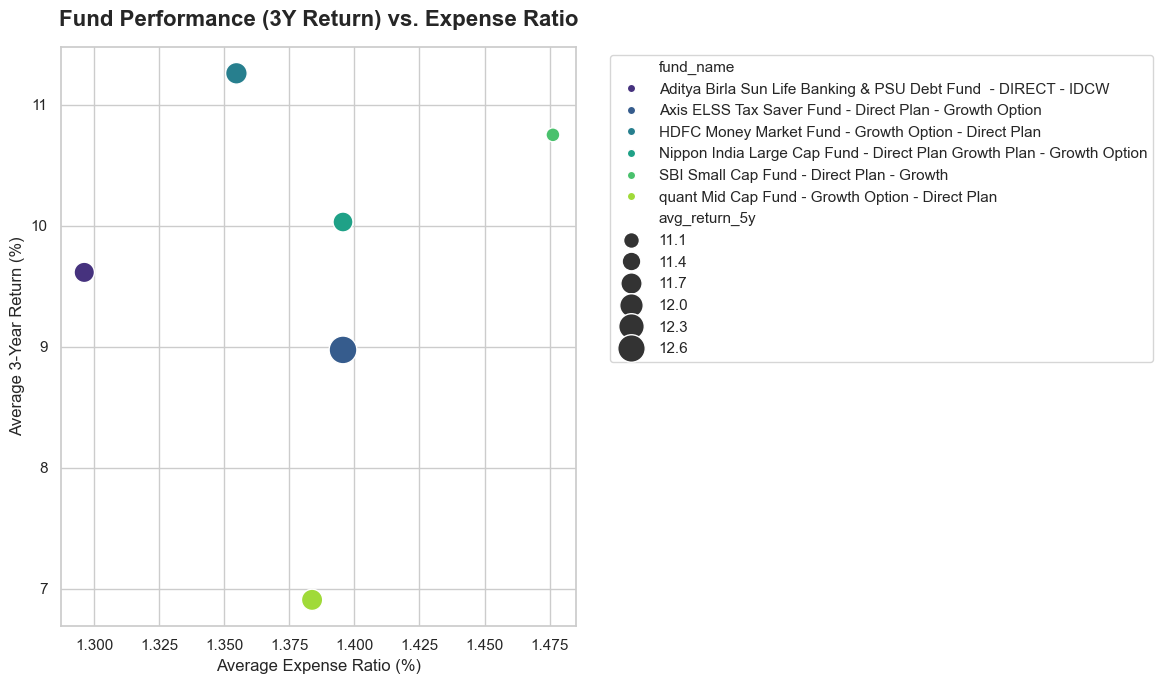

Saved Performance vs Expense Ratio chart.


In [5]:
# 4. Performance vs. Expense Ratio
query_perf = """
SELECT 
    df.fund_name,
    df.category,
    AVG(fp.return_1y) as avg_return_1y,
    AVG(fp.return_3y) as avg_return_3y,
    AVG(fp.return_5y) as avg_return_5y,
    AVG(fp.expense_ratio) as avg_expense_ratio
FROM fact_performance fp
JOIN dim_fund df ON fp.fund_key = df.fund_key
GROUP BY df.fund_name, df.category;
"""
df_perf = pd.read_sql_query(query_perf, conn)

# Scatter plot: 3Y Returns vs. Expense Ratio
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_perf, 
    x='avg_expense_ratio', 
    y='avg_return_3y', 
    hue='fund_name', 
    size='avg_return_5y', 
    sizes=(100, 400),
    palette='viridis', 
    legend='brief'
)

plt.title("Fund Performance (3Y Return) vs. Expense Ratio", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Average Expense Ratio (%)", fontsize=12)
plt.ylabel("Average 3-Year Return (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save
plt.savefig("../reports/charts/performance_vs_expense.png", dpi=300)
plt.show()
print("Saved Performance vs Expense Ratio chart.")

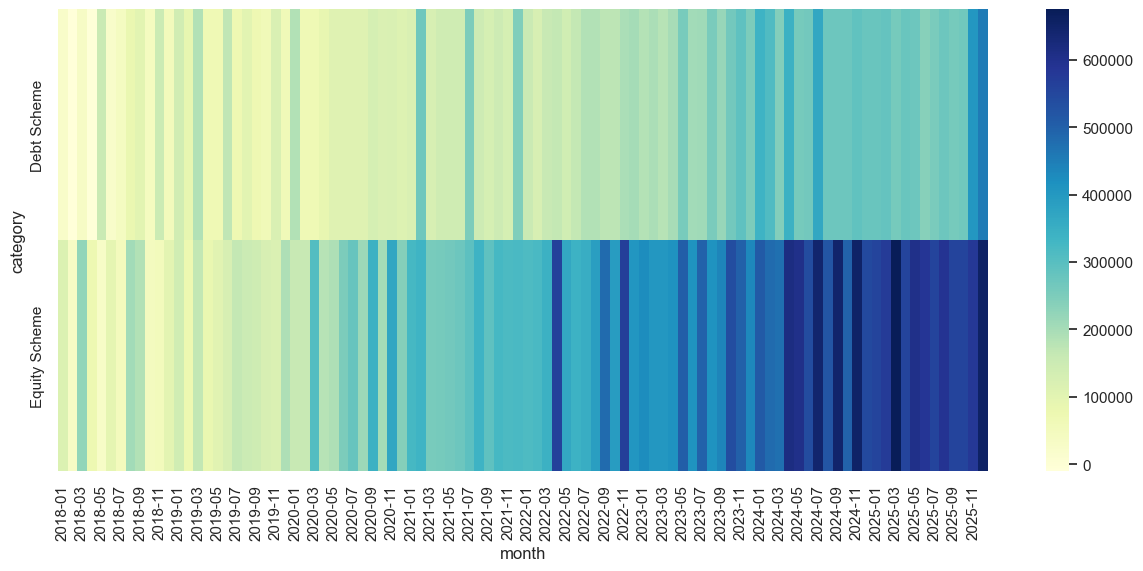

In [6]:
# 5. Category Net Inflow Heatmap
query_inflow = """
SELECT 
    df.category,
    strftime('%Y-%m-01', dd.full_date) as month,
    SUM(CASE WHEN ft.transaction_type = 'Redemption' THEN -ft.amount ELSE ft.amount END) as net_inflow
FROM fact_transactions ft
JOIN dim_fund df ON ft.fund_key = df.fund_key
JOIN dim_date dd ON ft.date_key = dd.date_key
GROUP BY df.category, strftime('%Y-%m-01', dd.full_date)
"""
inflow = pd.read_sql_query(query_inflow, conn)
inflow['month'] = pd.to_datetime(inflow['month']).dt.strftime('%Y-%m')

pivot = inflow.pivot_table(
    index="category",
    columns="month",
    values="net_inflow"
)

plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.savefig("../reports/charts/category_heatmap.png")
plt.show()

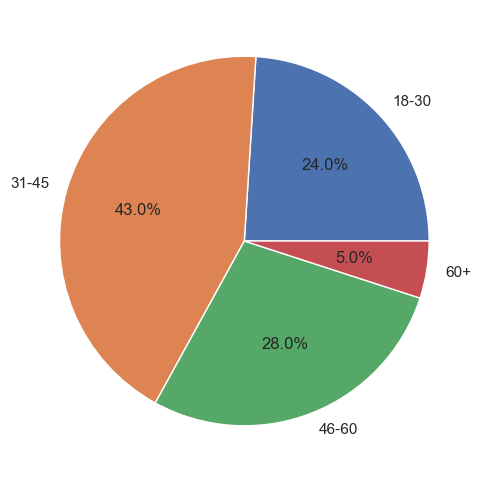

In [7]:
# 6. Investor Age Distribution
investor = pd.read_csv("../data/processed/investor_demographics.csv")

age = investor.groupby(
    "age_group"
).size()

plt.pie(
    age,
    labels=age.index,
    autopct="%1.1f%%"
)

plt.savefig("../reports/charts/age_pie.png")
plt.show()

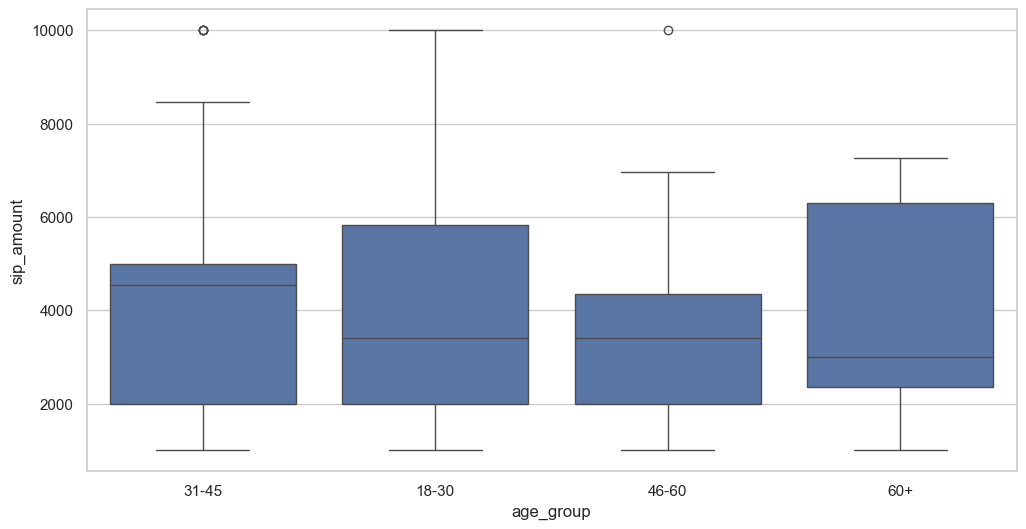

In [8]:
# 7. Investor Age vs SIP Amount Boxplot
sns.boxplot(
    data=investor,
    x="age_group",
    y="sip_amount"
)

plt.savefig("../reports/charts/age_boxplot.png")
plt.show()

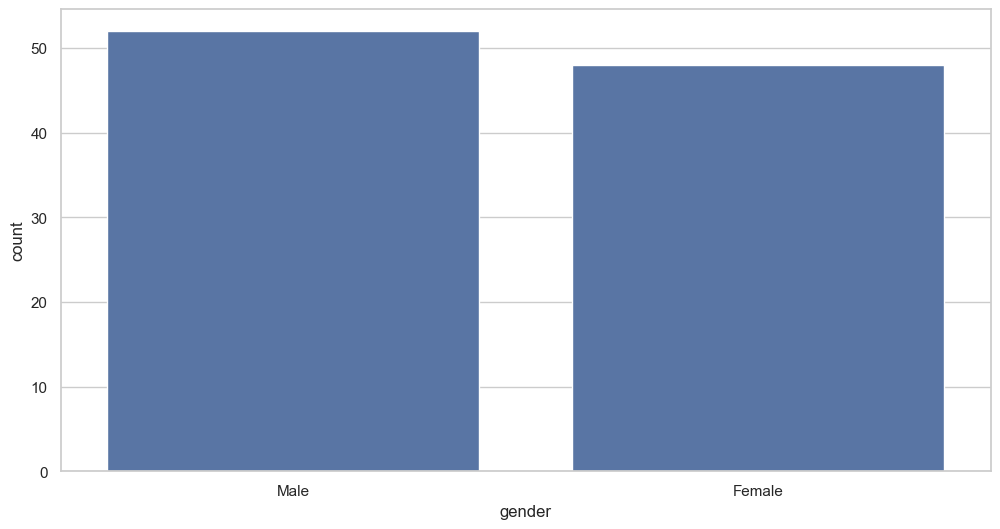

In [9]:
# 8. Investor Gender Split
sns.countplot(
    data=investor,
    x="gender"
)

plt.savefig("../reports/charts/gender_split.png")
plt.show()

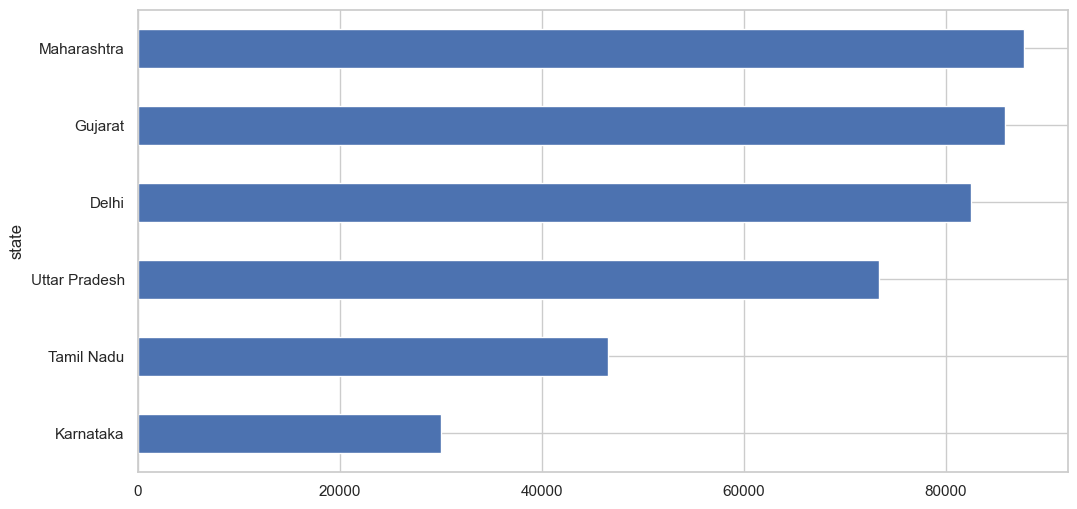

In [10]:
# 9. State-wise SIP Amount Distribution
state = investor.groupby(
    "state"
)["sip_amount"].sum()

state.sort_values().plot.barh()

plt.savefig("../reports/charts/state_sip.png")
plt.show()

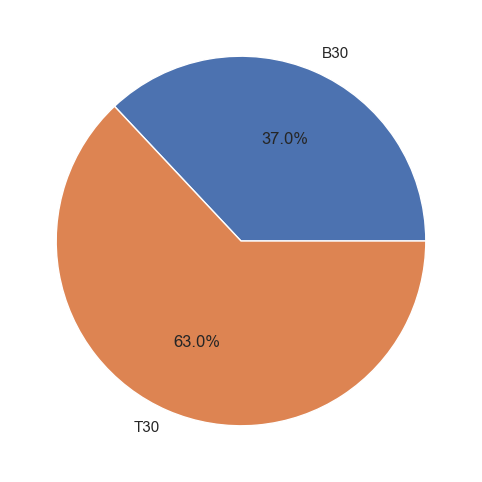

In [11]:
# 10. Investor Distribution by City Tier (T30 vs B30)
tier = investor.groupby("city_tier").size()

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.savefig("../reports/charts/t30_b30.png")
plt.show()

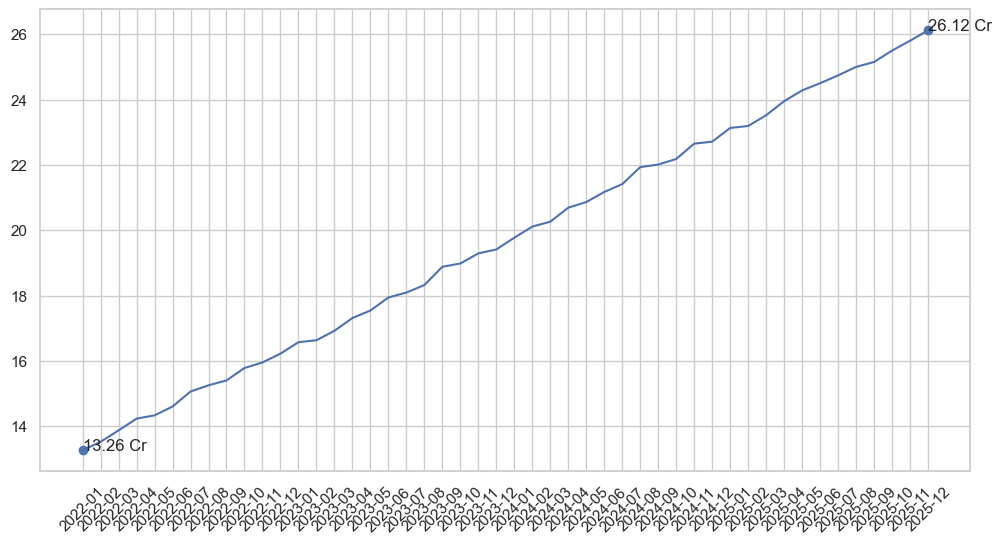

In [12]:
# 11. Folio Growth Over Time
folio = pd.read_csv("../data/processed/folio_growth.csv")

plt.figure(figsize=(12, 6))
plt.plot(
    folio["month"],
    folio["folios_cr"]
)

plt.scatter(
    ["2022-01","2025-12"],
    [13.26,26.12]
)

plt.annotate(
    "13.26 Cr",
    ("2022-01",13.26)
)

plt.annotate(
    "26.12 Cr",
    ("2025-12",26.12)
)

plt.xticks(rotation=45)
plt.savefig("../reports/charts/folio_growth.png")
plt.show()

/var/folders/rc/9j4p8rqs3_l7zkv7njn9q9yc0000gn/T/ipykernel_15670/1594414509.py:17: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = pivot.pct_change()


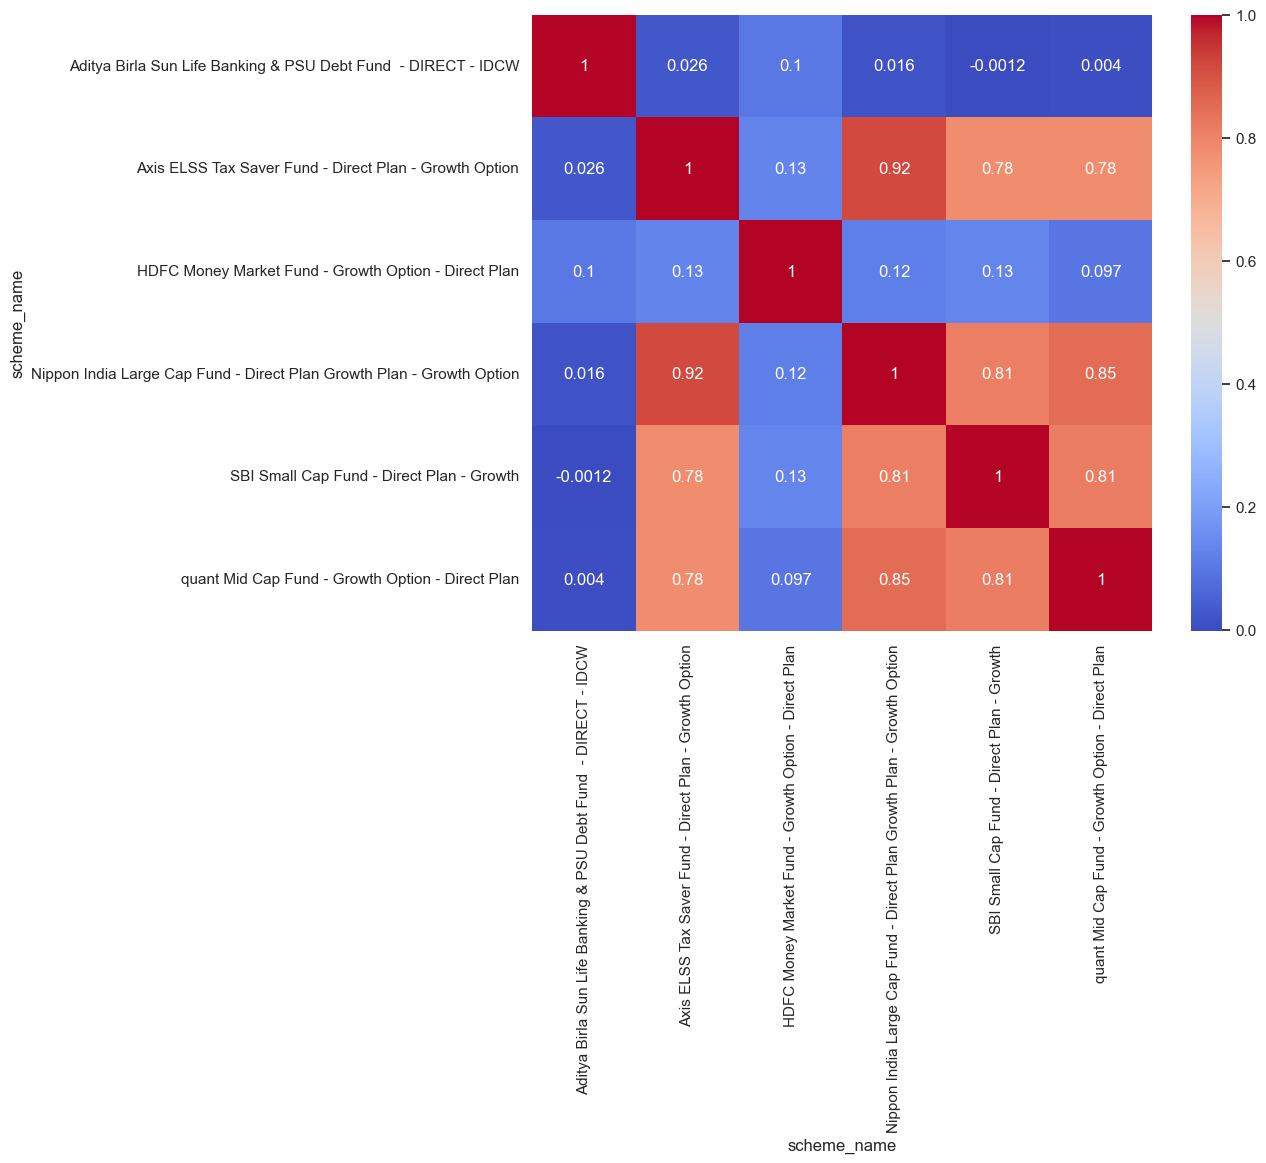

In [13]:
# 12. Fund Return Correlation Heatmap
# Drop any potential duplicates on date and scheme_name before pivoting
nav_p = nav.drop_duplicates(subset=["date", "scheme_name"])

top10 = nav_p[
    nav_p.scheme_name.isin(
        nav_p.scheme_name.unique()[:10]
    )
]

pivot = top10.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

returns = pivot.pct_change()
corr = returns.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.savefig("../reports/charts/correlation.png")
plt.show()

In [14]:
# 13. Portfolio Sector Allocation Donut Chart
holdings = pd.read_csv("../data/processed/holdings.csv")

sector = holdings.groupby(
    "sector"
)["weight"].sum()

fig = px.pie(
    values=sector.values,
    names=sector.index,
    hole=0.55,
    title="Portfolio Sector Allocation"
)

# Save chart as static PNG image
fig.write_image("../reports/charts/sector_donut.png")

# Display the interactive plot
fig.show()

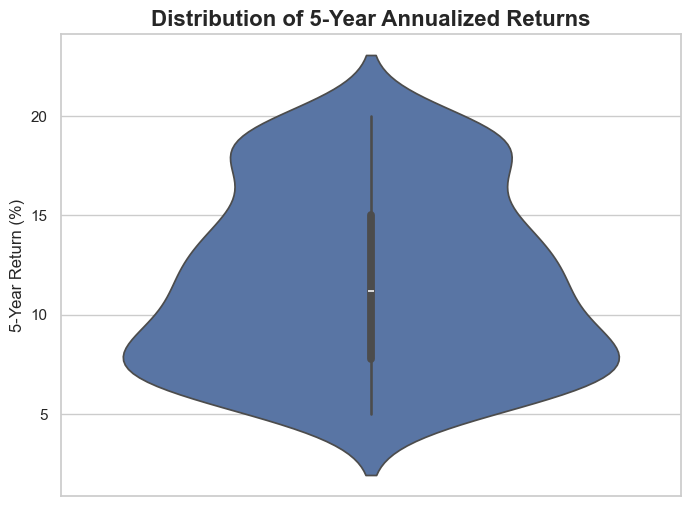

In [15]:
# 14. 5-Year Return Distribution Violin Plot
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=performance,
    y="return_5y"
)

plt.title("Distribution of 5-Year Annualized Returns", fontsize=16, fontweight='bold')
plt.ylabel("5-Year Return (%)", fontsize=12)
plt.savefig("../reports/charts/performance_violin.png")
plt.show()

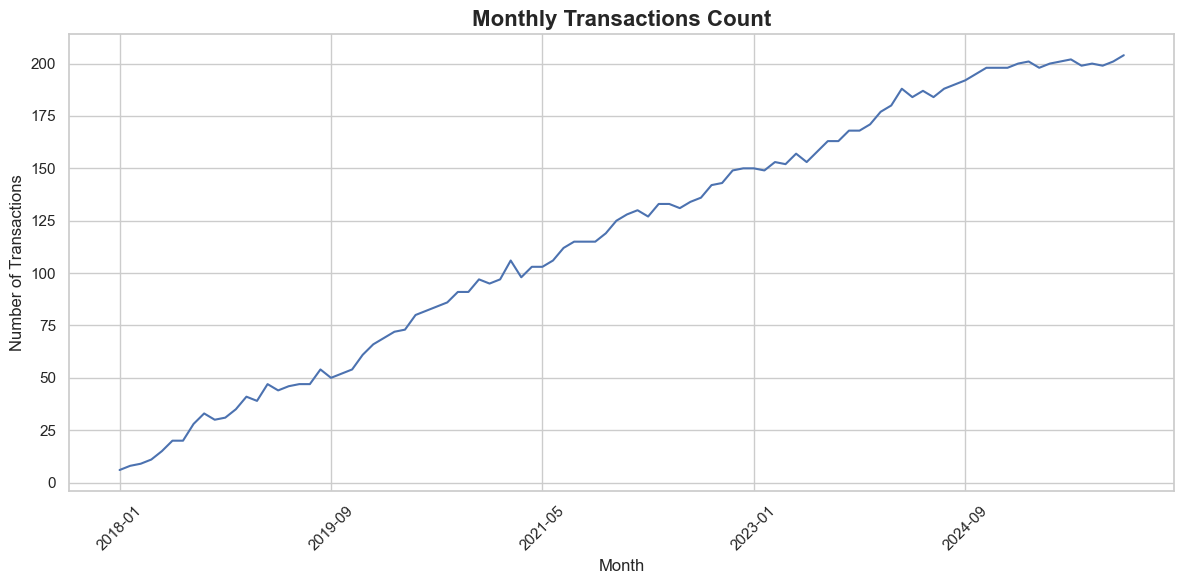

In [16]:
# 15. Monthly Transactions Count Plot
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")
transactions['month'] = pd.to_datetime(transactions['transaction_date']).dt.strftime('%Y-%m')

plt.figure(figsize=(12, 6))
monthly_tx = transactions.groupby("month").size()
monthly_tx.plot()

plt.title("Monthly Transactions Count", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/charts/monthly_transactions.png")
plt.show()

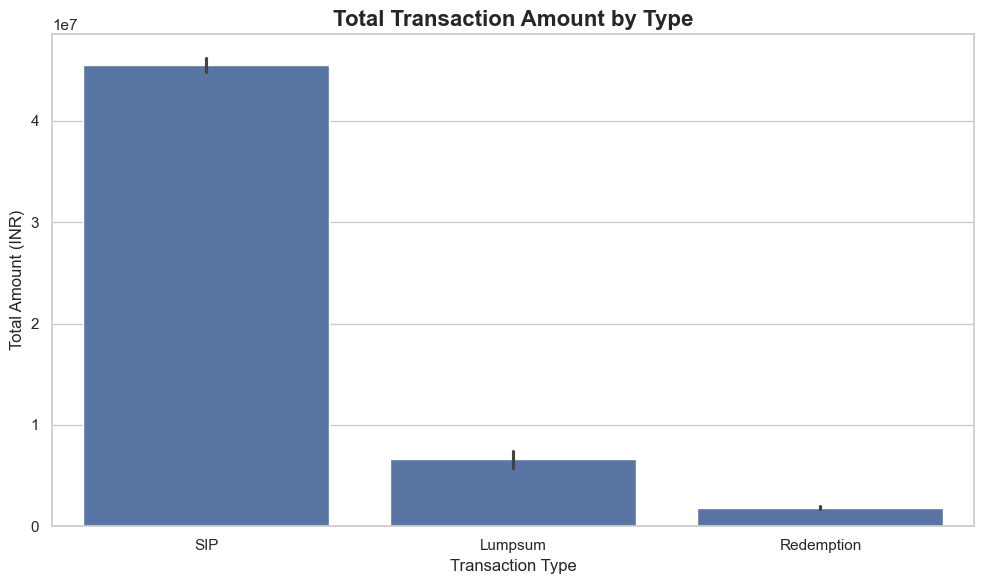

In [17]:
# 16. Total Transaction Amount by Type
plt.figure(figsize=(10, 6))
sns.barplot(
    data=transactions,
    x="transaction_type",
    y="amount",
    estimator=sum
)

plt.title("Total Transaction Amount by Type", fontsize=16, fontweight='bold')
plt.xlabel("Transaction Type", fontsize=12)
plt.ylabel("Total Amount (INR)", fontsize=12)
plt.tight_layout()

plt.savefig("../reports/charts/transactions_by_type.png")
plt.show()

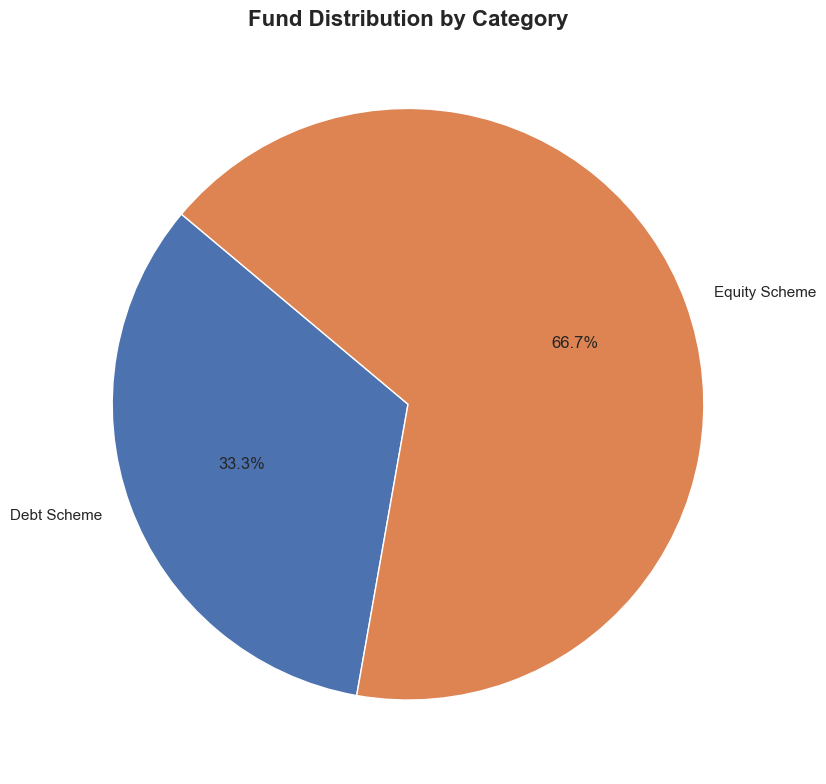

In [18]:
# 17. Fund Distribution by Category
fund = pd.read_csv("../data/raw/fund_master.csv")
category = fund.groupby("category").size()

plt.figure(figsize=(10, 8))
plt.pie(
    category,
    labels=category.index,
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Fund Distribution by Category", fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig("../reports/charts/fund_categories.png")
plt.show()

In [19]:
conn.close()
print("Database connection closed.")

Database connection closed.
